# Mundial26 — Phase 2: Baseline Classifier

**Goal:** build the first real predictive model. We compute an **Elo rating** for every
national team from 150+ years of results, then train classifiers to predict whether a
match ends in a home win, draw, or away win.

This baseline gives us a number to beat. In Phase 3, the Dixon–Coles goals model has to
do better than this — and if it can't, we keep the simpler model. That's honest ML.

**Two ideas that make this a *real* project, not a toy:**
1. **Elo ratings** — a principled, self-updating measure of team strength.
2. **Time-based split** — we train on older matches and test on recent ones, so the model
   never "sees the future." A random split would leak information and inflate the score.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, log_loss, classification_report
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Load data & build the outcome label
We load the raw results and rebuild the label, so this notebook runs independently of Phase 1.

In [2]:
results = pd.read_csv("../data/raw/results.csv", parse_dates=["date"])
results = results.sort_values("date").reset_index(drop=True)

def outcome(r):
    if r["home_score"] > r["away_score"]: return "home_win"
    if r["home_score"] < r["away_score"]: return "away_win"
    return "draw"

results["result"] = results.apply(outcome, axis=1)
print("Matches:", len(results))
results[["date","home_team","away_team","home_score","away_score","neutral","result"]].tail()

Matches: 49477


,date,home_team,away_team,home_score,away_score,neutral,result
49472,2026-06-27,Colombia,Portugal,NaN,NaN,True,draw
49473,2026-06-27,Panama,England,NaN,NaN,True,draw
49474,2026-06-27,Algeria,Austria,NaN,NaN,True,draw
49475,2026-06-27,Jordan,Argentina,NaN,NaN,True,draw
49476,2026-06-27,Croatia,Ghana,NaN,NaN,True,draw


## 3. Compute Elo ratings

Every team starts at 1500. After each match we nudge ratings based on the result vs what
was *expected* from the rating gap. Beating a stronger team gains more points than beating
a weaker one. We add a home-field bonus when the match isn't at a neutral site.

For each match we record each team's rating **before** the game — those become our features
(using post-match ratings would leak the result).

In [3]:
def compute_elo(df, k=30, hfa=65, base=1500):
    elos = {}
    home_pre, away_pre = [], []
    for r in df.itertuples():
        eh = elos.get(r.home_team, base)
        ea = elos.get(r.away_team, base)
        home_pre.append(eh)
        away_pre.append(ea)
        adj = 0 if r.neutral else hfa            # home advantage, only if not neutral
        exp_h = 1 / (1 + 10 ** ((ea - (eh + adj)) / 400))
        if r.home_score > r.away_score:   sh = 1.0
        elif r.home_score < r.away_score: sh = 0.0
        else:                             sh = 0.5
        elos[r.home_team] = eh + k * (sh - exp_h)
        elos[r.away_team] = ea + k * ((1 - sh) - (1 - exp_h))
    df = df.copy()
    df["home_elo"] = home_pre
    df["away_elo"] = away_pre
    df["elo_diff"] = df["home_elo"] - df["away_elo"]
    return df, elos

results, final_elos = compute_elo(results)
results[["date","home_team","away_team","home_elo","away_elo","elo_diff","result"]].tail()

,date,home_team,away_team,home_elo,away_elo,elo_diff,result
49472,2026-06-27,Colombia,Portugal,1923.237009,1930.896368,-7.659359,draw
49473,2026-06-27,Panama,England,1737.912453,1912.138924,-174.226471,draw
49474,2026-06-27,Algeria,Austria,1818.789888,1841.227521,-22.437634,draw
49475,2026-06-27,Jordan,Argentina,1675.042954,2057.093620,-382.050666,draw
49476,2026-06-27,Croatia,Ghana,1876.821473,1592.503344,284.318129,draw


### Sanity check: do the top-rated teams make sense?
If Elo is working, the strongest footballing nations should sit at the top.

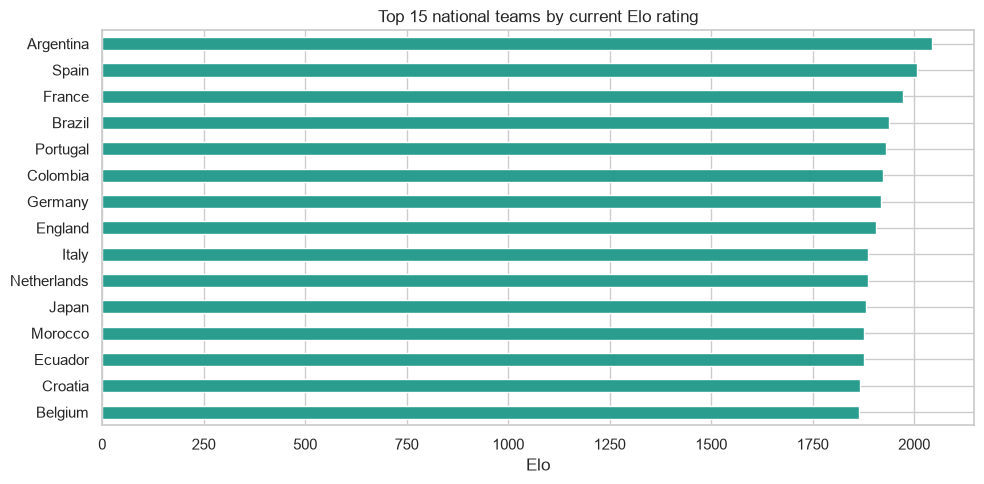

Argentina      2045.0
Spain          2008.0
France         1973.0
Brazil         1938.0
Portugal       1931.0
Colombia       1924.0
Germany        1917.0
England        1905.0
Italy          1886.0
Netherlands    1885.0
Japan          1882.0
Morocco        1876.0
Ecuador        1876.0
Croatia        1867.0
Belgium        1863.0
dtype: float64

In [4]:
top = pd.Series(final_elos).sort_values(ascending=False).head(15)
ax = top.sort_values().plot(kind="barh", color="#2a9d8f")
ax.set_title("Top 15 national teams by current Elo rating")
ax.set_xlabel("Elo")
plt.tight_layout(); plt.show()
top.round(0)

## 4. Features & time-based split

Features: the two ratings, their difference, and the neutral-site flag.

We train on everything **before 2018** and test on **2018 onward** (which includes the
2018 and 2022 World Cups). This mimics reality: predicting matches you haven't seen yet.

In [5]:
results["neutral_int"] = results["neutral"].astype(int)
features = ["home_elo", "away_elo", "elo_diff", "neutral_int"]

# Elo needs history to warm up; drop the earliest era where ratings are meaningless
data = results[results["date"] >= "1950-01-01"].copy()

train = data[data["date"] < "2018-01-01"]
test  = data[data["date"] >= "2018-01-01"]

le = LabelEncoder()
y_train = le.fit_transform(train["result"])
y_test  = le.transform(test["result"])
X_train, X_test = train[features], test[features]

print(f"Train: {len(train)} matches | Test: {len(test)} matches")
print("Classes:", list(le.classes_))

Train: 37959 matches | Test: 8180 matches
Classes: ['away_win', 'draw', 'home_win']


## 5. Train models

We compare four:
- **Dummy** — always predicts the most common outcome. The bar everything must clear.
- **Logistic Regression** — simple, interpretable linear model.
- **Random Forest** — captures non-linear patterns.
- **XGBoost** — gradient boosting, usually the strongest tabular model.

We score with **accuracy** and **log loss**. Log loss rewards well-calibrated probabilities
(not just the right pick), which is what we actually care about for a forecasting system.

In [6]:
models = {
    "Dummy (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.9, eval_metric="mlogloss", random_state=42),
}

rows = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    proba = model.predict_proba(X_test)
    preds = model.predict(X_test)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Log loss": log_loss(y_test, proba, labels=list(range(len(le.classes_)))),
    })

scores = pd.DataFrame(rows).set_index("Model").round(4)
scores

,Accuracy,Log loss
Model,,
Dummy (most frequent),0.4748,18.9295
Logistic Regression,0.5941,0.8797
Random Forest,0.5917,0.8852
XGBoost,0.5912,0.8873


## 6. Read the results

A couple of things to look for:
- Every real model should beat the **Dummy** on log loss (lower is better).
- Accuracy in the high-40s / low-50s% is normal and *expected* for football — draws are
  genuinely hard to predict, and upsets happen. Anyone claiming 80%+ is overfitting.
- The best model is the one with the **lowest log loss**, not necessarily the highest accuracy.

In [7]:
best_name = scores["Log loss"].idxmin()
print("Best model by log loss:", best_name)
best = fitted[best_name]

preds = best.predict(X_test)
print(classification_report(y_test, preds, target_names=le.classes_))

Best model by log loss: Logistic Regression
              precision    recall  f1-score   support

    away_win       0.57      0.60      0.59      2367
        draw       0.37      0.01      0.02      1929
    home_win       0.61      0.88      0.72      3884

    accuracy                           0.59      8180
   macro avg       0.51      0.50      0.44      8180
weighted avg       0.54      0.59      0.51      8180



### Where does it struggle? (the confusion matrix)
Watch the **draw** row — almost every football model under-predicts draws, because a draw
looks like "neither team was clearly better," which is hard to call in advance.

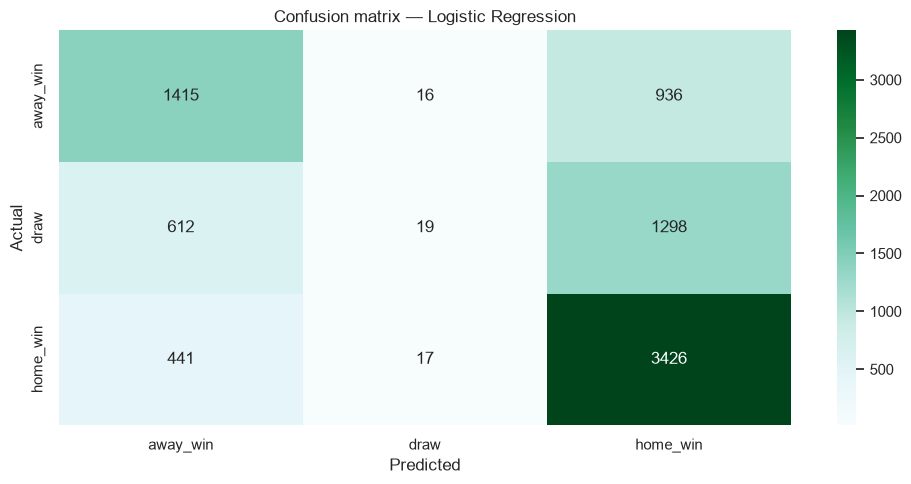

In [8]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout(); plt.show()

## 7. What drives the predictions?

In [9]:
if best_name == "Logistic Regression":
    coefs = best.named_steps["logisticregression"].coef_
    imp = pd.DataFrame(coefs, columns=features, index=le.classes_).T
    print(imp.round(3))
elif hasattr(best, "feature_importances_"):
    imp = pd.Series(best.feature_importances_, index=features).sort_values()
    imp.plot(kind="barh", color="#264653")
    plt.title(f"Feature importance — {best_name}"); plt.tight_layout(); plt.show()
    print(imp.round(3))

             away_win   draw  home_win
home_elo       -0.253  0.045     0.208
away_elo        0.241  0.059    -0.301
elo_diff       -0.444 -0.013     0.457
neutral_int     0.171 -0.041    -0.129


## 8. Save the model & ratings

We save the trained model and the final Elo ratings. Phase 4's simulation will load these
to rate the actual 2026 teams and play out the bracket.

In [10]:
import os, json, joblib
os.makedirs("../models", exist_ok=True)

joblib.dump(best, "../models/baseline_model.joblib")
joblib.dump(le, "../models/label_encoder.joblib")
with open("../models/elo_ratings.json", "w") as f:
    json.dump({k: round(v, 1) for k, v in final_elos.items()}, f, indent=2)

print("Saved baseline_model.joblib, label_encoder.joblib, elo_ratings.json to ../models/")

Saved baseline_model.joblib, label_encoder.joblib, elo_ratings.json to ../models/


---
### What's next (Phase 3)
This baseline predicts *outcomes* directly. Phase 3 takes a different, more principled
route: a **Dixon–Coles model** that predicts the *number of goals* each team scores, then
derives win/draw/loss probabilities from that. It naturally handles draws better and is the
approach used by professional football modellers. We'll compare its log loss head-to-head
against this baseline — and keep whichever wins.